In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
df = pd.read_excel('Data_online_retail_II_edited.xlsx')
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-2010
...,...,...,...,...,...,...,...,...,...
1047866,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2010-2011
1047867,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2010-2011
1047868,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2010-2011
1047869,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,2010-2011


## Project goal (define the problem clearly)

We have transaction-level online retail data with:
- `Invoice` (order id)
- `InvoiceDate` (timestamp)
- `Customer ID` (customer id)
- `StockCode` + `Description` (product)
- `Quantity`, `Price`
- `Country`
- `Year`

### Decisions we want to support
By the end, we’ll produce insights + recommendations for decisions like:
- Which customers are most valuable / at-risk?
- Which products/countries drive revenue?
- What are the sales trends and seasonality?
- What basket patterns exist (what items are bought together)?

### Core KPIs (we’ll compute)
- Revenue = `Quantity` × `Price`
- Orders, units sold, unique customers
- Average order value (AOV)
- Repeat rate / purchase frequency
- RFM segments (Recency, Frequency, Monetary)


In [27]:
# Understand the structure of the data

df.shape, df.columns.tolist()

((1047871, 9),
 ['Invoice',
  'StockCode',
  'Description',
  'Quantity',
  'InvoiceDate',
  'Price',
  'Customer ID',
  'Country',
  'Year'])

In [28]:
# Types, missingness, and time range

print(df.dtypes)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

print('Date range:', df['InvoiceDate'].min(), '→', df['InvoiceDate'].max())

missing = df.isna().mean().sort_values(ascending=False)
missing_df = (missing * 100).to_frame('missing_%')
missing_df[missing_df['missing_%'] > 0].head(20)

Invoice                 int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
Year                   object
dtype: object
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,missing_%
Customer ID,23.118399
Description,0.418181


In [29]:
# Quick summary stats

df.describe(include='all').T.head(25)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1047871.0,NaN,NaN,NaN,537608.149932,489434.0,515305.0,537638.0,561006.0,581587.0,26662.450447
StockCode,1047871,5298,85123A,5694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1043489,5681,WHITE HANGING HEART T-LIGHT HOLDER,5783,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1047871.0,NaN,NaN,NaN,10.592409,-9600.0,1.0,3.0,10.0,80995.0,135.280988
InvoiceDate,1047871,NaN,NaN,NaN,2011-01-03 07:10:27.055716096,2009-12-01 07:45:00,2010-07-09 15:48:00,2010-12-07 15:28:00,2011-07-22 15:02:00,2011-12-09 12:50:00,NaN
Price,1047871.0,NaN,NaN,NaN,4.042002,0.0,1.25,2.1,4.13,25111.09,50.145884
Customer ID,805620.0,NaN,NaN,NaN,15331.85625,12346.0,13982.0,15271.0,16805.0,18287.0,1696.768395
Country,1047871,43,United Kingdom,964674,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1047871,2,2010-2011,532619,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Basic uniqueness checks (grain sanity)

print('Rows:', len(df))
print('Unique Invoices:', df['Invoice'].nunique())
print('Unique Customers:', df['Customer ID'].nunique())
print('Unique StockCodes:', df['StockCode'].nunique())
print('Countries:', df['Country'].nunique())

Rows: 1047871
Unique Invoices: 45330
Unique Customers: 5881
Unique StockCodes: 5298
Countries: 43


In [31]:
# Clean the data
# Common issues in this dataset type: cancellations/returns, zero/negative price, missing customer ids.

clean = df.copy()

# Standardize key columns
clean['Invoice'] = clean['Invoice'].astype(str).str.strip()
clean['StockCode'] = clean['StockCode'].astype(str).str.strip()
clean['Description'] = clean['Description'].astype(str).str.strip()

# Create revenue
clean['Revenue'] = clean['Quantity'] * clean['Price']

# Flag cancellations (some versions use Invoice starting with 'C')
clean['IsCancellation'] = clean['Invoice'].str.startswith('C', na=False)

# Basic validity filters for sales analysis
valid_sales = clean[
    (clean['Quantity'] > 0)
    & (clean['Price'] > 0)
    & (~clean['IsCancellation'])
    & (clean['InvoiceDate'].notna())
].copy()

print('All rows:', len(clean))
print('Valid sales rows:', len(valid_sales))
print('Dropped rows:', len(clean) - len(valid_sales))

# Missing Customer ID is common; keep rows, but note that customer-level analysis will drop missing IDs
print('Missing Customer ID (all):', clean['Customer ID'].isna().mean().round(4))
print('Missing Description (all):', (clean['Description'].isna().mean() if 'Description' in clean else None))

All rows: 1047871
Valid sales rows: 1041669
Dropped rows: 6202
Missing Customer ID (all): 0.2312
Missing Description (all): 0.0


In [32]:
# Extra cleaning checks

# Duplicates
print('Duplicate rows:', valid_sales.duplicated().sum())

# Outlier scan (keep for review, don't drop automatically)
valid_sales[['Quantity','Price','Revenue']].describe(percentiles=[.5,.9,.95,.99]).T

Duplicate rows: 12061


,count,mean,std,min,50%,90%,95%,99%,max
Quantity,1041669.0,10.963467,126.515051,1.000,3.00,24.00,30.00,100.0,80995.00
Price,1041669.0,4.066068,50.293972,0.001,2.10,7.95,9.95,18.0,25111.09
Revenue,1041669.0,20.123026,202.828220,0.001,9.96,33.00,60.00,183.6,168469.60


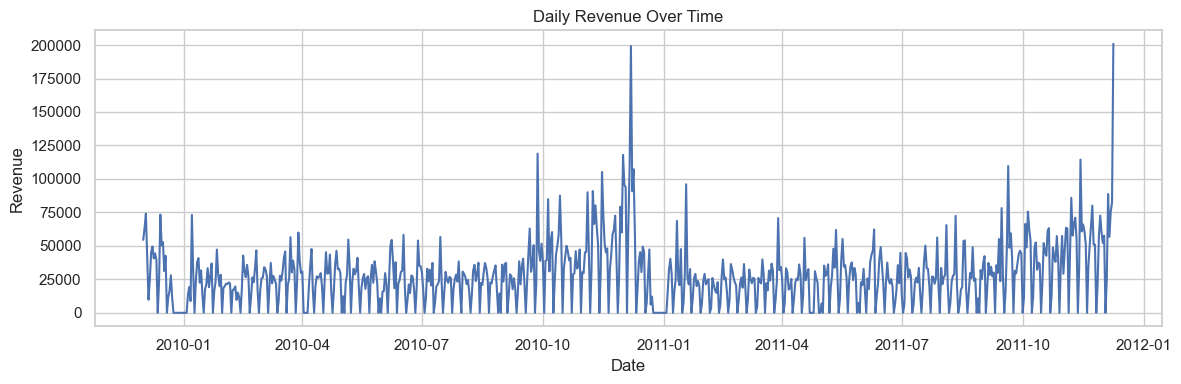

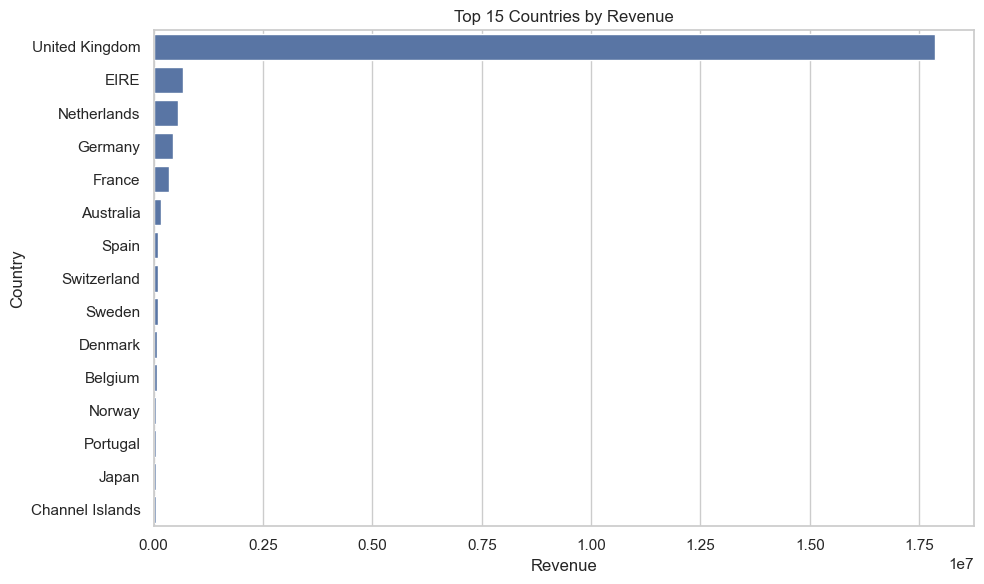

,StockCode,Description,Revenue
1875,22423,REGENCY CAKESTAND 3 TIER,344563.25
5584,M,Manual,340716.28
5583,DOT,DOTCOM POSTAGE,322657.48
4970,85123A,WHITE HANGING HEART T-LIGHT HOLDER,262931.16
3335,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3694,47566,PARTY BUNTING,149187.05
4939,85099B,JUMBO BAG RED RETROSPOT,148823.92
4612,84879,ASSORTED COLOUR BIRD ORNAMENT,132187.92
5586,POST,POSTAGE,127597.42
1465,22086,PAPER CHAIN KIT 50'S CHRISTMAS,123141.54


In [33]:
# Explore the data (EDA)

sns.set_theme(style='whitegrid')

# Revenue over time (daily)
daily = (
    valid_sales
    .set_index('InvoiceDate')
    .resample('D')['Revenue']
    .sum()
    .rename('DailyRevenue')
    .reset_index()
)

plt.figure(figsize=(12,4))
sns.lineplot(data=daily, x='InvoiceDate', y='DailyRevenue')
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Top countries by revenue
country_rev = (
    valid_sales
    .groupby('Country', as_index=False)['Revenue']
    .sum()
    .sort_values('Revenue', ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(data=country_rev.head(15), y='Country', x='Revenue')
plt.title('Top 15 Countries by Revenue')
plt.tight_layout()
plt.show()

# Top products by revenue
product_rev = (
    valid_sales
    .groupby(['StockCode','Description'], as_index=False)['Revenue']
    .sum()
    .sort_values('Revenue', ascending=False)
)
product_rev.head(20)

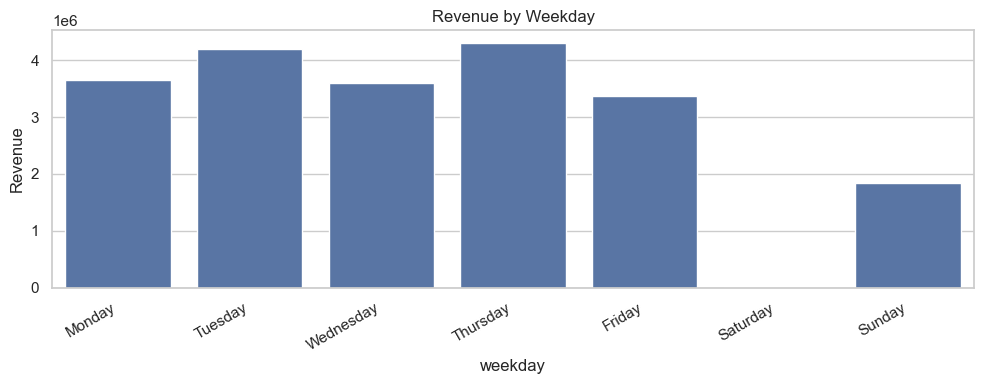

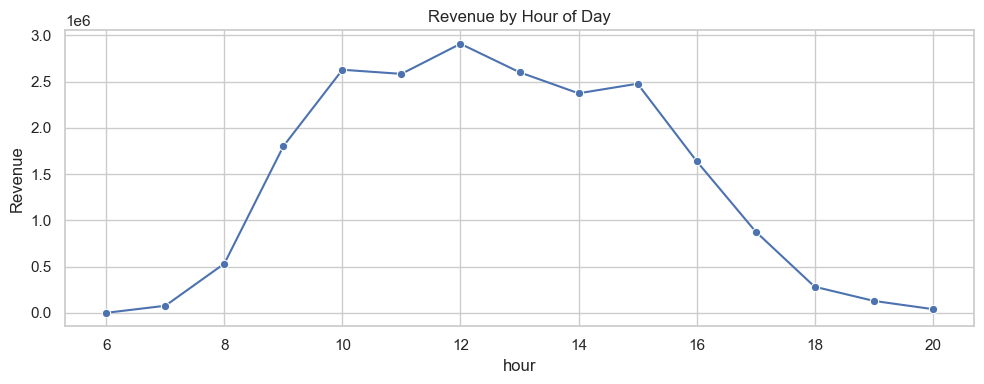

In [34]:
# Identify patterns and relationships

# Revenue by weekday / hour (seasonality within week/day)
tmp = valid_sales.copy()
tmp['weekday'] = tmp['InvoiceDate'].dt.day_name()
tmp['hour'] = tmp['InvoiceDate'].dt.hour

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_rev = tmp.groupby('weekday', as_index=False)['Revenue'].sum()
weekday_rev['weekday'] = pd.Categorical(weekday_rev['weekday'], categories=weekday_order, ordered=True)
weekday_rev = weekday_rev.sort_values('weekday')

plt.figure(figsize=(10,4))
sns.barplot(data=weekday_rev, x='weekday', y='Revenue')
plt.xticks(rotation=30, ha='right')
plt.title('Revenue by Weekday')
plt.tight_layout()
plt.show()

hour_rev = tmp.groupby('hour', as_index=False)['Revenue'].sum()
plt.figure(figsize=(10,4))
sns.lineplot(data=hour_rev, x='hour', y='Revenue', marker='o')
plt.title('Revenue by Hour of Day')
plt.tight_layout()
plt.show()

In [35]:
# Create useful features: customer-level RFM

# Customer-level analysis needs Customer ID
cust_sales = valid_sales[valid_sales['Customer ID'].notna()].copy()

snapshot_date = cust_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = (
    cust_sales
    .groupby('Customer ID')
    .agg(
        Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
        Frequency=('Invoice', 'nunique'),
        Monetary=('Revenue', 'sum'),
    )
    .reset_index()
)

rfm[['Recency','Frequency','Monetary']].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,5878.0,201.331916,209.338707,1.00,26.0000,96.000,380.00,739.00
Frequency,5878.0,6.289384,13.009406,1.00,1.0000,3.000,7.00,398.00
Monetary,5878.0,3018.616737,14737.731040,2.95,348.7625,898.915,2307.09,608821.65


In [36]:
# Improved RFM scoring (1–5) + meaningful segments

rfm_scored = rfm.copy()

# Use quintiles so scores are on a true 1–5 scale.
# qcut can fail when many tied values exist at quantile boundaries;
# ranking first makes the bins stable.

r_rank = rfm_scored['Recency'].rank(method='first', ascending=True)
rfm_scored['R'] = pd.qcut(r_rank, 5, labels=[5,4,3,2,1]).astype(int)

f_rank = rfm_scored['Frequency'].rank(method='first', ascending=True)
rfm_scored['F'] = pd.qcut(f_rank, 5, labels=[1,2,3,4,5]).astype(int)

m_rank = rfm_scored['Monetary'].rank(method='first', ascending=True)
rfm_scored['M'] = pd.qcut(m_rank, 5, labels=[1,2,3,4,5]).astype(int)

rfm_scored['RFM_Score'] = rfm_scored['R'] + rfm_scored['F'] + rfm_scored['M']

# Segment rules (business-friendly)
# We use (R) for recency and (FM) for overall value / engagement
rfm_scored['FM'] = (rfm_scored['F'] + rfm_scored['M']) / 2

def rfm_segment(row):
    r, fm = row['R'], row['FM']

    if (r >= 4) and (fm >= 4):
        return 'Champions'
    if (r >= 3) and (fm >= 4):
        return 'Loyal'
    if (r >= 4) and (fm <= 2):
        return 'New Customers'
    if (r == 3) and (fm >= 3):
        return 'Potential Loyalists'
    if (r <= 2) and (fm >= 4):
        return "Can't Lose Them"
    if (r <= 2) and (fm >= 3):
        return 'At Risk'
    if (r == 3) and (fm <= 2):
        return 'Needs Attention'
    if (r == 2) and (fm <= 2):
        return 'About To Sleep'
    if (r == 1) and (fm <= 2):
        return 'Lost'
    return 'Others'

rfm_scored['Segment'] = rfm_scored.apply(rfm_segment, axis=1)

rfm_scored['Segment'].value_counts()

Segment
Champions              1316
Others                 1082
Lost                    834
About To Sleep          545
At Risk                 439
Loyal                   435
New Customers           363
Needs Attention         317
Potential Loyalists     302
Can't Lose Them         245
Name: count, dtype: int64

In [37]:
# Segment metrics

# Order-level table for AOV etc.
orders = (
    cust_sales
    .groupby(['Invoice','Customer ID'], as_index=False)
    .agg(
        OrderRevenue=('Revenue','sum'),
        OrderItems=('Quantity','sum'),
        OrderLines=('StockCode','count'),
        OrderDate=('InvoiceDate','min'),
    )
)

# Attach segment to each customer
cust_segment = rfm_scored[['Customer ID','Segment','Recency','Frequency','Monetary']].copy()

orders_seg = orders.merge(cust_segment[['Customer ID','Segment']], on='Customer ID', how='left')

segment_customer_counts = cust_segment['Segment'].value_counts().rename('Customers')
segment_revenue = cust_segment.groupby('Segment')['Monetary'].sum().rename('Revenue')

seg_summary = pd.concat([segment_customer_counts, segment_revenue], axis=1).fillna(0)
seg_summary['%Customers'] = seg_summary['Customers'] / seg_summary['Customers'].sum() * 100
seg_summary['%Revenue'] = seg_summary['Revenue'] / seg_summary['Revenue'].sum() * 100

# Per-segment averages
seg_recency = cust_segment.groupby('Segment')['Recency'].mean().rename('AvgRecency_days')
seg_frequency = cust_segment.groupby('Segment')['Frequency'].mean().rename('AvgFrequency_orders')
seg_aov = orders_seg.groupby('Segment')['OrderRevenue'].mean().rename('AvgOrderValue')

seg_metrics = pd.concat([seg_summary, seg_recency, seg_frequency, seg_aov], axis=1).sort_values('Revenue', ascending=False)
seg_metrics.round(2)

,Customers,Revenue,%Customers,%Revenue,AvgRecency_days,AvgFrequency_orders,AvgOrderValue
Segment,,,,,,,
Champions,1316,12201375.00,22.39,68.77,19.79,16.90,548.48
Loyal,435,1765479.91,7.40,9.95,102.70,9.20,441.26
Can't Lose Them,245,1133257.97,4.17,6.39,344.51,8.58,539.39
Others,1082,1097937.31,18.41,6.19,132.86,3.07,330.21
At Risk,439,576195.20,7.47,3.25,375.02,3.55,370.07
Potential Loyalists,302,360368.31,5.14,2.03,110.79,3.79,315.01
Lost,834,224890.13,14.19,1.27,560.92,1.18,229.48
About To Sleep,545,169481.15,9.27,0.96,318.90,1.25,248.51
New Customers,363,112445.46,6.18,0.63,28.48,1.43,216.24


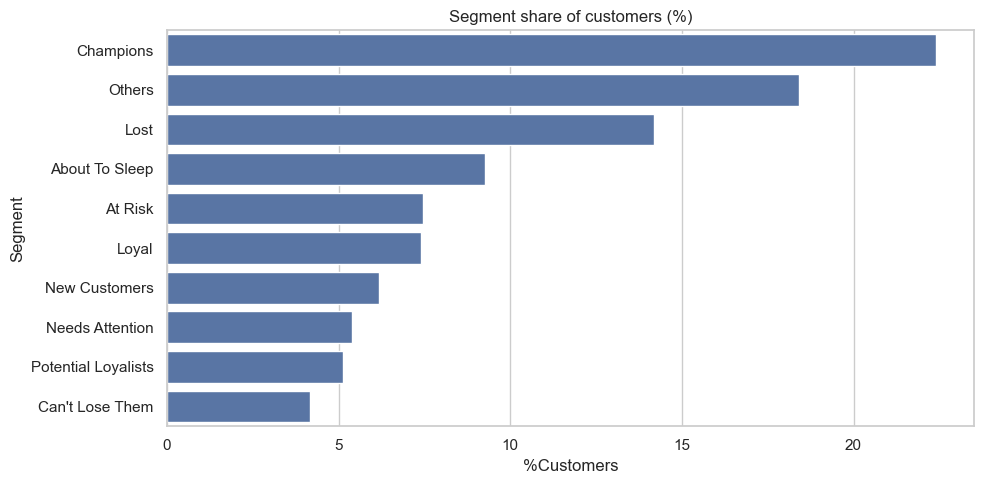

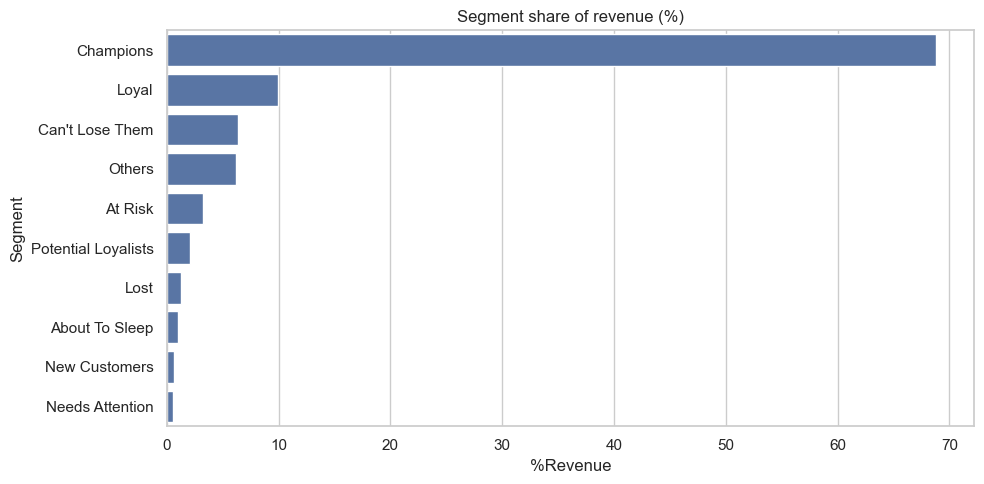

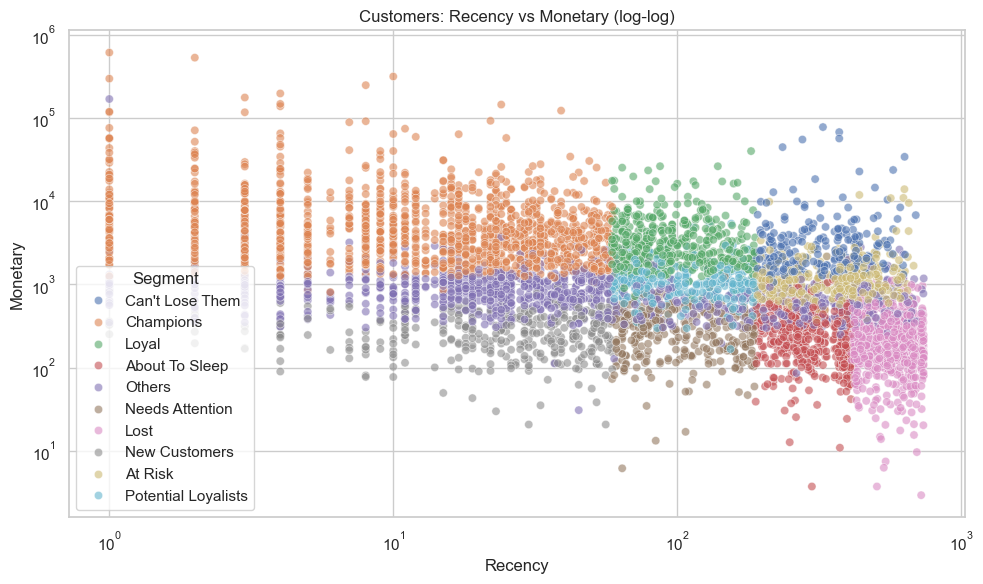

In [38]:
# Visualize segments

seg_plot = seg_metrics.reset_index().rename(columns={'index':'Segment'})

plt.figure(figsize=(10,5))
sns.barplot(data=seg_plot, y='Segment', x='%Customers', order=seg_plot.sort_values('%Customers', ascending=False)['Segment'])
plt.title('Segment share of customers (%)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=seg_plot, y='Segment', x='%Revenue', order=seg_plot.sort_values('%Revenue', ascending=False)['Segment'])
plt.title('Segment share of revenue (%)')
plt.tight_layout()
plt.show()

# Recency vs Monetary colored by Segment
plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm_scored, x='Recency', y='Monetary', hue='Segment', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title('Customers: Recency vs Monetary (log-log)')
plt.tight_layout()
plt.show()

## Business recommendations by segment

- **Champions**: VIP perks, early access, exclusive bundles, referral rewards.
- **Loyal**: points/loyalty tiers, cross-sell based on baskets, subscriptions (if relevant).
- **Potential Loyalists**: onboarding journey, personalized recommendations, next-purchase incentive.
- **New Customers**: welcome offer, ensure great first delivery experience, highlight best-sellers.
- **Needs Attention / About To Sleep**: targeted promos, reminders, reactivation email/SMS.
- **At Risk**: win-back campaign, survey/feedback, incentives on categories they bought before.
- **Can't Lose Them**: high-touch outreach, service recovery, stronger win-back incentives.
- **Lost**: low-cost reactivation attempts only; exclude from costly campaigns.

Use the segment KPIs above to decide where to spend budget: prioritize segments with high **%Revenue** and/or high **%Customers**.


In [39]:
# Modeling option 1: Customer segmentation via clustering (RFM)

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = rfm_scored[['Recency','Frequency','Monetary']].copy()

# log-transform to reduce skew
X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

k = 5
km = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm_scored['Cluster'] = km.fit_predict(X_scaled)

rfm_scored.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().sort_values('Monetary', ascending=False)

,Recency,Frequency,Monetary
Cluster,,,
3,18.166667,32.759740,21171.499619
1,48.942857,9.101931,3721.819311
2,291.607038,3.796921,1415.520743
4,32.704645,2.500438,688.300685
0,418.680074,1.246906,263.811244


MAE (last 12 weeks): 90774.66


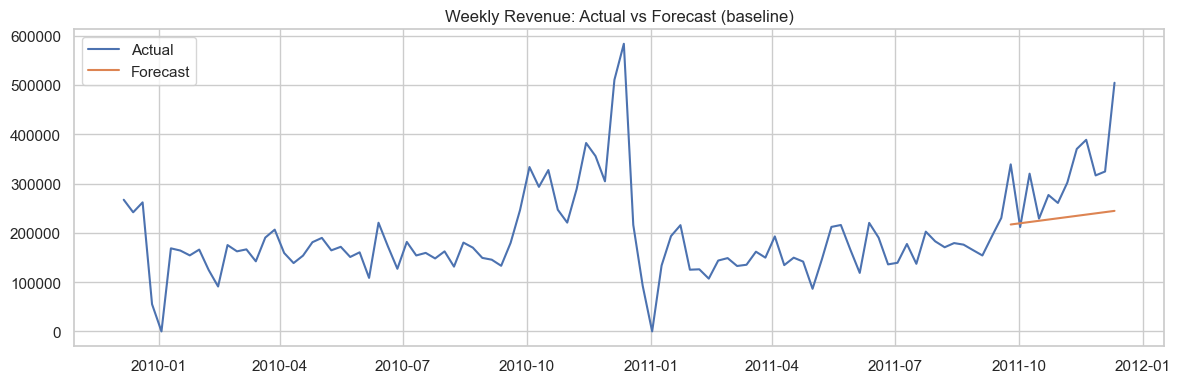

In [40]:
# Modeling option 2: Simple revenue forecasting baseline (weekly)

from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge

weekly = (
    valid_sales
    .set_index('InvoiceDate')
    .resample('W')['Revenue']
    .sum()
    .rename('Revenue')
    .to_frame()
)

weekly['t'] = np.arange(len(weekly))
weekly['weekofyear'] = weekly.index.isocalendar().week.astype(int)
weekly['year'] = weekly.index.year

X = weekly[['t','weekofyear','year']]
y = weekly['Revenue']

# Train/test split: last 12 weeks as test
split = max(1, len(weekly) - 12)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
print('MAE (last 12 weeks):', round(mae, 2))

fc = weekly.copy()
fc.loc[X_test.index, 'Forecast'] = pred

plt.figure(figsize=(12,4))
plt.plot(fc.index, fc['Revenue'], label='Actual')
plt.plot(fc.index, fc['Forecast'], label='Forecast')
plt.title('Weekly Revenue: Actual vs Forecast (baseline)')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# Modeling option 3: Repeat / churn prediction (binary classification)
# Label: will the customer purchase in the next 90 days after their snapshot date?

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression

horizon_days = 90

# Build customer snapshots at their last purchase date
last_purchase = cust_sales.groupby('Customer ID')['InvoiceDate'].max().rename('LastPurchase').reset_index()

# For each customer, did they purchase again within horizon after their last purchase?
# (In this dataset, last purchase is at end; so instead we create an earlier snapshot for learning.)

# Create a snapshot date = 2011-09-01 (example) so label can look forward
snapshot = cust_sales['InvoiceDate'].max() - pd.Timedelta(days=horizon_days)

hist = cust_sales[cust_sales['InvoiceDate'] <= snapshot].copy()
future = cust_sales[cust_sales['InvoiceDate'] > snapshot].copy()

# Features from history
snapshot_date = snapshot + pd.Timedelta(days=1)
rfm_snap = (
    hist.groupby('Customer ID')
    .agg(
        Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
        Frequency=('Invoice','nunique'),
        Monetary=('Revenue','sum'),
    )
    .reset_index()
)

# Label: bought in the future window
buyers_future = set(future['Customer ID'].unique())
rfm_snap['WillBuyNext90d'] = rfm_snap['Customer ID'].isin(buyers_future).astype(int)

X = rfm_snap[['Recency','Frequency','Monetary']]
y = rfm_snap['WillBuyNext90d']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)

print('ROC AUC:', roc_auc_score(y_test, proba).round(3))
print(classification_report(y_test, pred))

ROC AUC: 0.785
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       748
           1       0.68      0.65      0.67       573

    accuracy                           0.72      1321
   macro avg       0.71      0.71      0.71      1321
weighted avg       0.72      0.72      0.72      1321



## Walkthrough: what each section does (and how to read the outputs)

Use this as a guide while you run the notebook top → bottom.

### 1) Load the dataset (`df`)
**Code**: `df = pd.read_excel('Data_online_retail_II_edited.xlsx')`

**Output**: a preview of rows and columns.
- **What it means**: this is transaction-line level data (one row ≈ one product line on an invoice).
- **Key fields**:
  - `Invoice`: order id (sometimes cancellations start with `C`)
  - `InvoiceDate`: timestamp of the order
  - `Customer ID`: customer identifier (can be missing)
  - `StockCode` + `Description`: product
  - `Quantity`, `Price`: units and unit price
  - `Country`, `Year`

### 2) Project goal (markdown)
**Output**: a checklist of decisions and KPIs.
- **What it means**: this notebook is set up to produce business insights (revenue drivers + customer segments) and optional predictive models.

### 3) Structure checks (shape/columns)
**Code**: `df.shape, df.columns.tolist()`

**Output**:
- `df.shape`: (rows, columns)
- column list

**How to interpret**: sanity-check that the file loaded correctly and has the expected fields.

### 4) Data types, missingness, date range
**Code**: prints `df.dtypes`, converts `InvoiceDate` to datetime, prints min/max dates, and shows missing %.

**Output**:
- **Types**: confirms which columns are numeric vs text vs datetime.
- **Date range**: tells you the time coverage (important for trends/forecasting).
- **Missing %**: highlights data quality issues.

**Typical interpretation for this dataset**:
- `Customer ID` often has many missing values → customer-level analysis uses only rows where `Customer ID` exists.

### 5) Quick summary stats
**Code**: `df.describe(include='all').T.head(25)`

**Output**: descriptive statistics.
- **What to look for**: outliers in `Price`/`Quantity`, unexpected nulls, odd distributions.

### 6) Grain sanity / uniqueness
**Code**: counts unique invoices, customers, stockcodes, countries.

**Output**: unique counts.
- **What it means**: helps confirm scale and whether IDs look reasonable.

### 7) Cleaning + creating analysis tables (`clean`, `valid_sales`)
**Code**:
- creates `clean = df.copy()`
- standardizes text columns
- creates `Revenue = Quantity * Price`
- flags cancellations with `IsCancellation`
- filters to `valid_sales` with:
  - `Quantity > 0`
  - `Price > 0`
  - not a cancellation
  - valid `InvoiceDate`

**Output**:
- counts of all rows vs valid sales rows
- missingness notes

**How to interpret**:
- **`valid_sales`** is the dataset you should use for revenue/trend/customer analytics.
- If many rows are dropped: it’s usually cancellations/returns or invalid pricing.

### 8) Extra cleaning checks
**Code**: duplicates count + distribution stats for `Quantity`, `Price`, `Revenue`.

**Output**:
- `Duplicate rows`: number of exact duplicate lines
- percentiles table

**How to interpret**:
- Expect some extreme values; we’re not dropping automatically—this is for review.

### 9) EDA: revenue trends, top countries, top products
**Code**:
- `daily` revenue time series + line chart
- `country_rev` bar chart (top 15)
- `product_rev` table (top 20)

**Outputs & interpretation**:
- **Daily revenue line**: seasonality, spikes, trend changes.
- **Top countries**: concentration risk/opportunity.
- **Top products**: best sellers; watch for non-product codes like `POST` (postage) that can distort “top products”.

### 10) Patterns: weekday / hour
**Code**: revenue aggregated by weekday and hour.

**Output**: 2 plots.
- **Interpretation**: identifies when customers buy; useful for staffing, promo timing, email sends.

### 11) Customer-level RFM base table (`rfm`)
**Code**: creates `cust_sales = valid_sales` filtered to non-null `Customer ID`, then builds:
- `Recency`: days since last purchase
- `Frequency`: number of unique invoices
- `Monetary`: total revenue

**Output**: summary stats for R, F, M.
- **Interpretation**: confirms the customer base behavior (typical recency, repeat purchasing, revenue skew).

### 12) Improved RFM scoring (1–5) + segments (`rfm_scored`)
**Code**:
- creates `R`, `F`, `M` scores on a 1–5 scale (quintiles)
- creates `Segment` using business rules

**Output**: segment counts.

**How to interpret**:
- **Champions / Loyal**: recent + high value
- **At Risk / Can’t Lose Them**: not recent, but historically valuable
- **Lost**: long time since last purchase + low value

### 13) Segment KPIs (`seg_metrics`)
**Code**:
- builds order-level table `orders`
- merges customer segments
- computes per-segment:
  - **Customers** + **%Customers**
  - **Revenue** + **%Revenue**
  - **AvgRecency_days**, **AvgFrequency_orders**, **AvgOrderValue**

**Output**: `seg_metrics` table.

**How to interpret**:
- Use **%Revenue** to prioritize where business impact is largest.
- Use **%Customers** to size operational effort.
- Use **AOV** to decide whether discounting is appropriate (high AOV segments often need less discounting).

### 14) Segment visualizations
**Code**:
- bar chart: %Customers
- bar chart: %Revenue
- scatter: Recency vs Monetary (log scale)

**Interpretation**:
- Confirms whether segments are distinct.
- Shows whether revenue is concentrated in a small set of high-value customers.

### 15) Business recommendations by segment (markdown)
**Output**: playbook by segment.
- **How to use**: pair this with `seg_metrics` to choose campaigns and budget.

---

## Optional modeling sections (run only if you need prediction)

### 16) Clustering on RFM (`Cluster`)
**Output**: average RFM per cluster.
- **Interpretation**: data-driven segments; you can compare clusters to rule-based segments.

### 17) Weekly revenue forecasting baseline
**Output**:
- MAE (last 12 weeks)
- actual vs forecast plot

**Interpretation**:
- This is a baseline. If error is high, we add richer time features (lags/rolling means/holidays) or a dedicated forecasting model.

### 18) Repeat / churn prediction (90-day horizon)
**Output**:
- ROC AUC
- classification report

**Interpretation**:
- If ROC AUC is meaningfully above 0.5, the model has predictive signal.
- Use predicted probabilities to target win-back campaigns efficiently.


## Decision-making inferences (what to do with the results)

Use the tables/plots you generated to drive concrete decisions.

### A) Customer strategy (from `seg_metrics`)
Look at **%Revenue** and **%Customers** by segment.

- **If Champions + Loyal contribute a large %Revenue**:
  - **Decision**: protect retention and margin.
  - **Actions**: VIP perks, early access, referral, bundles (avoid heavy discounting).

- **If At Risk / Can’t Lose Them contribute meaningful %Revenue**:
  - **Decision**: run a win-back program (highest ROI target group).
  - **Actions**: personalized offers based on past categories, service checks, timed reminders.

- **If New Customers are large but low %Revenue**:
  - **Decision**: improve second-purchase conversion.
  - **Actions**: onboarding email/SMS sequence, “2nd order” incentive, best-seller recommendations.

- **If Lost is very large**:
  - **Decision**: stop spending expensive budget here.
  - **Actions**: low-cost reactivation only; focus spend on At Risk instead.

**How to choose budget** (simple rule): prioritize segments with high **%Revenue** × high **lift potential** (At Risk / Can’t Lose Them usually wins).

### B) Product & inventory decisions (from top products + basket pairs)
- **Top products by revenue**:
  - **Decision**: protect stock availability and pricing.
  - **Actions**: ensure inventory coverage, negotiate supplier terms, reduce stockouts.

- **Basket pairs** (co-purchases):
  - **Decision**: create bundles and cross-sell placements.
  - **Actions**: “Frequently bought together” widgets, bundle discounts, co-located merchandising.

### C) Market expansion / operations (from top countries)
- **If revenue is concentrated in 1–2 countries**:
  - **Decision**: reduce concentration risk.
  - **Actions**: expand marketing/logistics to next-best countries, test localized promos.

- **If non-UK countries have high AOV (check segment/country splits later)**:
  - **Decision**: prioritize those markets for premium offers.

### D) Timing & campaign scheduling (from daily trend + weekday/hour)
- **If revenue spikes are seasonal**:
  - **Decision**: pre-plan inventory and campaigns.
  - **Actions**: stock earlier, schedule promos ahead of peak weeks.

- **If weekday/hour patterns are strong**:
  - **Decision**: time marketing to when customers buy.
  - **Actions**: send campaigns before peak hours/days; align staffing/dispatch.

### E) Data/ops issues to fix (from cleaning + outliers)
- **High cancellations/returns or many invalid rows**:
  - **Decision**: investigate operational causes.
  - **Actions**: QA on fulfillment, product quality, pricing errors, fraud checks.

### F) If you use models (optional)
- **Clustering**: use clusters as data-driven segments, then compute the same KPIs per cluster.
- **Forecasting**: use MAE to judge whether the baseline is good enough for planning; improve if error is too high.
- **Repeat/churn prediction**: use probability scores to target win-back messages instead of blasting all customers.


## Summary / conclusions (executive-ready)

### Executive summary (5–10 bullets)
Replace the bracketed placeholders after you run the notebook.

- **Overall performance**: Total valid sales revenue = **[£X]** across **[N]** invoices and **[N]** customers (customer-id known subset).
- **Revenue concentration**: Top **[k]** countries account for **[Y%]** of revenue (main market: **[Country]**).
- **Product concentration**: Top **[k]** products contribute **[Y%]** of revenue; protect availability and pricing for these SKUs.
- **Seasonality**: Revenue peaks in **[months/weeks]** and is strongest on **[weekday]** around **[hour range]** → schedule campaigns and staffing accordingly.
- **Customer value**: **Champions + Loyal** represent **[X%]** of customers but generate **[Y%]** of revenue.
- **Retention risk**: **At Risk + Can’t Lose Them** generate **[Y%]** of revenue → highest priority win-back segment.
- **New customer conversion**: **New Customers** are **[X%]** of customers with low frequency → focus on second-purchase conversion.
- **Operational issues**: **[Z%]** of rows were excluded by validity rules (returns/cancellations/invalid price) → investigate root causes.
- **Modeling results (if used)**:
  - Clustering: clusters reveal **[brief insight]**.
  - Forecasting: weekly baseline MAE = **[MAE]**; improve if planning requires lower error.
  - Churn/repeat: ROC AUC = **[AUC]**; use scores to target win-back efficiently.

### Final recommendations (action plan)
- **Protect high-value customers**: VIP perks + bundles for Champions/Loyal (avoid deep discounts).
- **Run win-back campaigns**: targeted offers for At Risk / Can’t Lose Them using prior purchase categories.
- **Improve onboarding**: automated journey for New Customers to drive a second order.
- **Inventory planning**: stock top products ahead of peak season; reduce stockouts on high-revenue SKUs.
- **Campaign timing**: send promos before peak weekday/hour to maximize conversion.

### What to paste into your report (from outputs)
- `seg_metrics` table (or top 6 segments)
- Top 10 countries by revenue
- Top 10 products by revenue
- Daily revenue trend plot
- Segment share plots (%Customers, %Revenue)


In [42]:
# Basket features (optional): frequently co-purchased items (top pairs)
# Note: this can be heavy on 1M+ rows; we sample invoices.

from itertools import combinations
from collections import Counter

sample_invoices = (
    valid_sales[['Invoice','Description']]
    .dropna()
    .groupby('Invoice')['Description']
    .apply(lambda s: sorted(set(s)))
)

# sample to keep runtime reasonable
sample_invoices = sample_invoices.sample(n=min(5000, len(sample_invoices)), random_state=42)

pair_counts = Counter()
for items in sample_invoices:
    for a, b in combinations(items, 2):
        pair_counts[(a, b)] += 1

pd.DataFrame(pair_counts.most_common(20), columns=['Pair','Count'])

,Pair,Count
0,"(RED HANGING HEART T-LIGHT HOLDER, WHITE HANGI...",163
1,"(STRAWBERRY CERAMIC TRINKET BOX, SWEETHEART CE...",158
2,"(WOODEN FRAME ANTIQUE WHITE, WOODEN PICTURE FR...",154
3,"(LUNCH BAG BLACK SKULL., LUNCH BAG CARS BLUE)",144
4,"(JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI)",137
5,"(HEART OF WICKER LARGE, HEART OF WICKER SMALL)",124
6,"(JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAG...",123
7,"(DOLLY GIRL LUNCH BOX, SPACEBOY LUNCH BOX)",121
8,"(LUNCH BAG CARS BLUE, LUNCH BAG WOODLAND)",121
9,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",120


## Modeling (only if needed)

This dataset supports several modeling directions. Common choices:
- **Customer segmentation**: clustering on RFM and behavioral features.
- **Forecasting**: predict future revenue (daily/weekly) for inventory planning.
- **Churn / repeat prediction**: who is likely to buy again soon.

If we don’t need prediction, we can stop at segmentation + insights + recommendations.


## Interpret results → insights → recommendations

When you run the notebook, we’ll extract:
- What drives revenue (countries, products, seasonality)
- Who matters most (RFM segments) and how to act on them
- What to fix in ops/data (returns/cancellations, pricing anomalies)

## Visualize key findings
- Daily revenue trend
- Top countries/products
- RFM segment distribution

## Summary / conclusions
We’ll finish with a short executive summary: 5–10 bullets that a manager can act on.
